# Sea Ice Volume Evaluation: Simulated vs. PIOMAS Observed

Compares **domain-integrated sea ice volume** (km³) -- simulated (FOSI truth, Stochastic UNet
Mean, Deterministic UNet, Bilinear) vs. observed (PIOMAS reanalysis, the same "obs" stand-in
used in `evaluation_plots.ipynb` -- see that notebook's "Observational comparison" section for
why PIOMAS, not a satellite product, is used) -- with a time series and a seasonal-cycle plot.

This is a companion to `evaluation_plots.ipynb`, which compares sea ice **thickness** (SIT,
m) pointwise/domain-mean. Volume differs from a domain-mean thickness comparison by weighting
each grid cell's thickness by its physical area, so it reflects total ice mass in the domain
rather than an area-agnostic average -- two methods with the same domain-mean SIT can still
have different volume if they disagree on *where* the ice is thick vs. thin relative to each
grid cell's true footprint.

**Caveat**: the model's test sub-domain (`bbox`, printed below) is a regional crop, not the
full Arctic basin -- so "volume" here means the ice volume contained within that sub-domain,
not pan-Arctic sea ice volume (the ~ 10,000-20,000 km³ numbers PIOMAS is usually cited for).

This notebook reads only the files written to `<output_dir>/eval_data/` by
`save_evaluation_data()` (same as `evaluation_plots.ipynb`) -- point `EVAL_DIR` below at a
run's `eval_data/` directory. Only meaningful for `--no-patches` runs (no single coherent
domain grid/area to integrate over for `--patches` runs).

Saved output: every figure/table below is also written to `saved_figs/<batch_name>/<run_name>/`
(same convention as `evaluation_plots.ipynb`), prefixed `v1_`/`v2_` so it doesn't collide with
that notebook's own numbered sections in the same folder.


In [1]:
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.spatial import cKDTree
from IPython.display import display


## Config

In [2]:
# Point this at a single run's eval_data/ directory
DIR = Path("/glade/work/skygale/_projects/SeaIceDownscaling/Version4/results/FOSI_2conv")
[print(D.name) for D in sorted(DIR.iterdir())]

RUN = "FOSI_nopatches_1990-2000_2010-2020_5280657.casper-pbs"
EVAL_DIR = DIR / RUN / "eval_data"
assert EVAL_DIR.exists(), f"EVAL_DIR does not exist: {EVAL_DIR}"

print("\nEVAL_DIR:", EVAL_DIR)


FOSI_nopatches_1960-1970_2010-2020_5280654.casper-pbs
FOSI_nopatches_1970-1980_2010-2020_5280655.casper-pbs
FOSI_nopatches_1980-1990_2010-2020_5280656.casper-pbs
FOSI_nopatches_1990-2000_2010-2020_5280657.casper-pbs
FOSI_nopatches_2000-2009_2010-2020_5280658.casper-pbs

EVAL_DIR: /glade/work/skygale/_projects/SeaIceDownscaling/Version4/results/FOSI_2conv/FOSI_nopatches_1990-2000_2010-2020_5280657.casper-pbs/eval_data


In [3]:
# Mirrors results/<batch_name>/<run_name>/, same as evaluation_plots.ipynb -- prefixed v1_/v2_
# below so these outputs don't collide with that notebook's own numbered sections.
SAVE_DIR = Path("saved_figs") / DIR.name / RUN
SAVE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to SAVE_DIR/<name>.png."""
    fig.savefig(SAVE_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


def save_table(df, name):
    """Save a table (DataFrame or Series) to SAVE_DIR/<name>.csv."""
    df.to_csv(SAVE_DIR / f"{name}.csv")


print("Saving figures/tables to:", SAVE_DIR.resolve())


Saving figures/tables to: /glade/work/skygale/_projects/SeaIceDownscaling/Version4/saved_figs/FOSI_2conv/FOSI_nopatches_1990-2000_2010-2020_5280657.casper-pbs


## Load everything

In [4]:
fields = np.load(EVAL_DIR / "fields.npz")

Y_base_phys = fields["Y_base_phys"]           # (N, 1, H, W) bilinear baseline
Y_pred_det_phys = fields["Y_pred_det_phys"]   # (N, 1, H, W) deterministic UNet
Y_pred_phys = fields["Y_pred_phys"]           # (N, 1, H, W) ensemble mean
Y_test_phys = fields["Y_test_phys"]           # (N, 1, H, W) truth
mask_test = fields["mask_test"]               # (N, C_mask, H, W) land mask, per test sample/tile

with open(EVAL_DIR / "tile_geometry.pkl", "rb") as f:
    tile_geometry = pickle.load(f)   # list of dicts: context_lon/lat, target_lon/lat per tile

with open(EVAL_DIR / "meta.json") as f:
    meta = json.load(f)

bbox = meta["bbox"]
use_patches = meta["use_patches"]

sample_times_df = pd.read_csv(EVAL_DIR / "sample_times.csv", parse_dates=["time"])

print("use_patches:", use_patches)
print("N samples:", Y_test_phys.shape[0], " |  target grid:", Y_test_phys.shape[-2:])
print("bbox:", bbox)


use_patches: False
N samples: 132  |  target grid: (150, 310)
bbox: {'lon_min': -190, 'lon_max': -140, 'lat_min': 60, 'lat_max': 80}


## Observational comparison: PIOMAS sea ice thickness

Same PIOMAS load/regrid as `evaluation_plots.ipynb`'s "Observational comparison" section --
see that notebook for the full rationale (PIOMAS is a model reanalysis, not a direct
satellite retrieval, but is the standard stand-in "obs" reference for basin-scale Arctic SIT
verification since no continuous satellite thickness record spans the full test period).
`piomas_regridded_phys` ends up `(N, 1, H, W)`, matching `Y_test_phys` etc., so its thickness
gets integrated into a volume exactly like every other method below.


In [5]:
PIOMAS_PATH = Path("/glade/campaign/cgd/ccr/yeager/OBS/seaice/PIOMAS/PIOMAS.hi.1978-2020.nc")


def load_piomas(path=PIOMAS_PATH):
    """PIOMAS monthly ice thickness ('hi', m) on its native curvilinear grid, with its
    decimal-year time axis converted to first-of-month Timestamps."""
    ds = xr.open_dataset(path)
    year = np.floor(ds["time"].values).astype(int)
    month = np.clip(np.round((ds["time"].values - year) * 12 + 1.5).astype(int), 1, 12)
    times = pd.to_datetime({"year": year, "month": month, "day": 1})
    return ds["hi"].values, ds["lat"].values, (ds["lon"].values % 360), times


def nearest_grid_indices(src_lat, src_lon, query_lat, query_lon):
    """Flat index into src_lat/src_lon.ravel() of the nearest source grid cell to each
    query point, via a 3D-Cartesian KDTree (avoids pole/dateline distortion that a plain
    lat/lon distance would have at these latitudes)."""
    def to_xyz(lat_deg, lon_deg):
        lat, lon = np.deg2rad(lat_deg), np.deg2rad(lon_deg)
        return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)
    tree = cKDTree(to_xyz(np.asarray(src_lat).ravel(), np.asarray(src_lon).ravel()))
    _, idx = tree.query(to_xyz(np.asarray(query_lat), np.asarray(query_lon)))
    return idx


def build_piomas_regridded(target_lat, target_lon, sample_times):
    """PIOMAS 'hi' regridded (nearest-neighbor) onto a 1D (target_lat, target_lon) grid,
    one field per entry of sample_times (nearest PIOMAS calendar month) -- shape
    (len(sample_times), 1, len(target_lat), len(target_lon)), matching Y_test_phys etc."""
    piomas_hi, piomas_lat, piomas_lon, piomas_times = load_piomas()

    tlat_2d, tlon_2d = np.meshgrid(target_lat, target_lon, indexing="ij")
    space_idx = nearest_grid_indices(piomas_lat, piomas_lon, tlat_2d.ravel(), tlon_2d.ravel())
    piomas_hi_flat = piomas_hi.reshape(piomas_hi.shape[0], -1)

    sample_times = pd.to_datetime(sample_times).values
    piomas_month_idx = np.abs(piomas_times.values[None, :] - sample_times[:, None]).argmin(axis=1)
    gap_days = np.abs(piomas_times.values[piomas_month_idx] - sample_times) / np.timedelta64(1, "D")
    if gap_days.max() > 45:
        print(f"Warning: largest sample-to-PIOMAS-month gap is {gap_days.max():.0f} days -- "
              "some test samples fall outside PIOMAS's 1978-2020 record.")

    regridded = piomas_hi_flat[piomas_month_idx][:, space_idx].reshape(
        len(sample_times), 1, len(target_lat), len(target_lon)
    )
    return regridded.astype(np.float32)


if use_patches:
    print("use_patches=True: no single coherent target grid to regrid PIOMAS onto -- skipping.")
else:
    geo_piomas = tile_geometry[0]
    piomas_regridded_phys = build_piomas_regridded(
        geo_piomas["target_lat"], geo_piomas["target_lon"], sample_times_df["time"]
    )
    print("piomas_regridded_phys:", piomas_regridded_phys.shape)


piomas_regridded_phys: (132, 1, 150, 310)


## Grid-cell area and domain sea ice volume

Each target-grid cell's physical area (km²) is estimated from its lat/lon spacing:
`area = (dlat_deg * km_per_deg) * (dlon_deg * km_per_deg * cos(lat))`, using a fixed
`km_per_deg = 111.0` (same approximation `evaluation_plots.ipynb`'s power-spectral-density
section uses for its km-conversion) with `cos(lat)` evaluated per-row rather than at a single
domain-mean latitude, since this domain spans a wide enough latitude range (see `bbox` above)
for that to matter for an area/volume number specifically.

Domain sea ice volume for a given method at one test time is then
`sum_cells(thickness_m * ocean_frac * area_km2) * 0.001` (the `0.001` converts the thickness
term from meters to km so the product comes out in km³) -- the same `ocean_weight` fractional
land mask used by `evaluation_plots.ipynb`'s domain-mean SIT section, applied here as an area
weight instead of an averaging weight.


In [6]:
if use_patches:
    print("use_patches=True: no single coherent domain grid to integrate an area/volume over -- skipping.")
else:
    geo = tile_geometry[0]
    target_lat, target_lon = geo["target_lat"], geo["target_lon"]
    H, W = len(target_lat), len(target_lon)

    KM_PER_DEG = 111.0
    dlat_deg = float(np.diff(target_lat).mean())
    dlon_deg = float(np.diff(target_lon).mean())

    dy_km = KM_PER_DEG * abs(dlat_deg)
    dx_km_per_row = KM_PER_DEG * abs(dlon_deg) * np.cos(np.deg2rad(target_lat))  # (H,)
    area_hw = dy_km * dx_km_per_row[:, None] * np.ones((1, W))                   # (H, W) km^2

    ocean_weight = (1.0 - mask_test[0, 0]).clip(0, 1)  # (H, W); same land mask for every no-patch sample
    ocean_area_hw = area_hw * ocean_weight

    print(f"Grid cell size: ~{dy_km:.1f} km (N-S) x ~{dx_km_per_row.mean():.1f} km (E-W, domain-mean)")
    print(f"Domain ocean area: {ocean_area_hw.sum():,.0f} km^2")

    def domain_volume_km3(field_phys):
        """field_phys: (N, 1, H, W) thickness in meters -> (N,) domain-integrated volume in km^3."""
        return (field_phys[:, 0] * ocean_area_hw[None, :, :]).sum(axis=(1, 2)) * 1e-3


Grid cell size: ~11.1 km (N-S) x ~4.2 km (E-W, domain-mean)
Domain ocean area: 1,287,785 km^2


## 1. Domain sea ice volume: time series

Domain-integrated volume at each test time, truth vs. each method vs. PIOMAS.

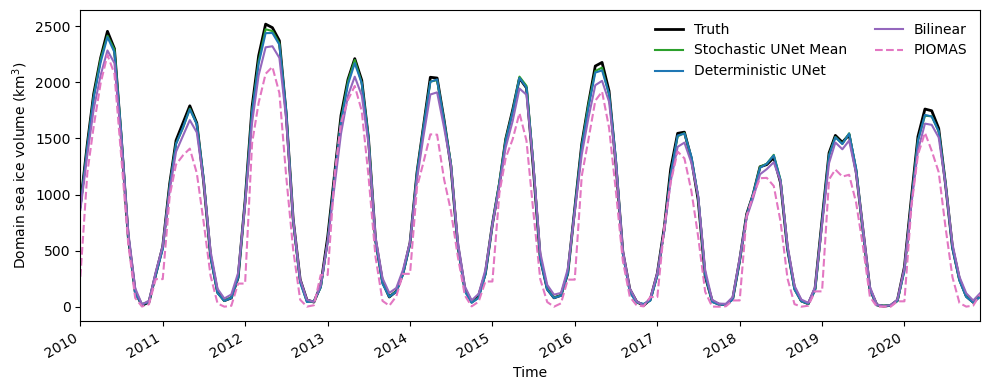

,Method,Mean volume (km^3),Bias vs. Truth (km^3),Bias vs. PIOMAS (km^3)
0,Truth,927.8,0.0,203.0
1,Stochastic UNet Mean,918.6,-9.2,193.8
2,Deterministic UNet,914.7,-13.1,189.9
3,Bilinear,892.1,-35.7,167.3
4,PIOMAS,724.8,-203.0,0.0


In [7]:
if use_patches:
    print("use_patches=True: skipping (no domain area to integrate over).")
else:
    vol_df = sample_times_df.copy()
    vol_df["truth"] = domain_volume_km3(Y_test_phys)
    vol_df["stochastic_unet_mean"] = domain_volume_km3(Y_pred_phys)
    vol_df["deterministic_unet"] = domain_volume_km3(Y_pred_det_phys)
    vol_df["bilinear"] = domain_volume_km3(Y_base_phys)
    vol_df["piomas"] = domain_volume_km3(piomas_regridded_phys)
    vol_df = vol_df.sort_values("time").reset_index(drop=True)
    save_table(vol_df, "v1_volume_timeseries_data")

    # ---- Customize here ----
    DATE_RANGE = None  # e.g. ("2006-01-01", "2010-12-31"), or None for all
    RESAMPLE = None    # e.g. "YS" (annual mean), "MS" (monthly), or None for raw samples
    METHODS = {
        "Truth":                ("truth", "black", "-"),
        "Stochastic UNet Mean": ("stochastic_unet_mean", "tab:green", "-"),
        "Deterministic UNet":   ("deterministic_unet", "tab:blue", "-"),
        "Bilinear":             ("bilinear", "tab:purple", "-"),
        "PIOMAS":               ("piomas", "tab:pink", "--"),
    }
    # -------------------------

    plot_df = vol_df
    if DATE_RANGE is not None:
        plot_df = plot_df[(plot_df["time"] >= DATE_RANGE[0]) & (plot_df["time"] <= DATE_RANGE[1])]
    if RESAMPLE is not None:
        plot_df = plot_df.set_index("time").resample(RESAMPLE).mean(numeric_only=True).reset_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    for label, (col, color, ls) in METHODS.items():
        ax.plot(plot_df["time"], plot_df[col], label=label, color=color, ls=ls, lw=2 if label == "Truth" else 1.5)
    ax.set_ylabel("Domain sea ice volume (km$^3$)")
    ax.set_xlabel("Time")
    ax.legend(fontsize=10, ncols=2, frameon=False)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.xlim(plot_df["time"].min(), plot_df["time"].max())
    save_fig(fig, "v1_volume_timeseries")
    plt.show()

    vol_summary_df = pd.DataFrame([
        {
            "Method": label,
            "Mean volume (km^3)": round(float(vol_df[col].mean()), 1),
            "Bias vs. Truth (km^3)": round(float(vol_df[col].mean() - vol_df["truth"].mean()), 1),
            "Bias vs. PIOMAS (km^3)": round(float(vol_df[col].mean() - vol_df["piomas"].mean()), 1),
        }
        for label, (col, _, _) in METHODS.items()
    ])
    save_table(vol_summary_df, "v1_volume_summary")
    display(vol_summary_df)


## 2. Domain sea ice volume: seasonal cycle (mean annual cycle)

Domain volume averaged by calendar month across all test years (climatology), truth vs. each
method vs. PIOMAS, plus each method's seasonal amplitude (max minus min month) -- checks
whether the freeze-thaw *volume* cycle's shape and amplitude are captured, independent of any
particular year's anomaly (companion to `evaluation_plots.ipynb`'s section 9, which does the
same thing for domain-mean thickness rather than integrated volume).

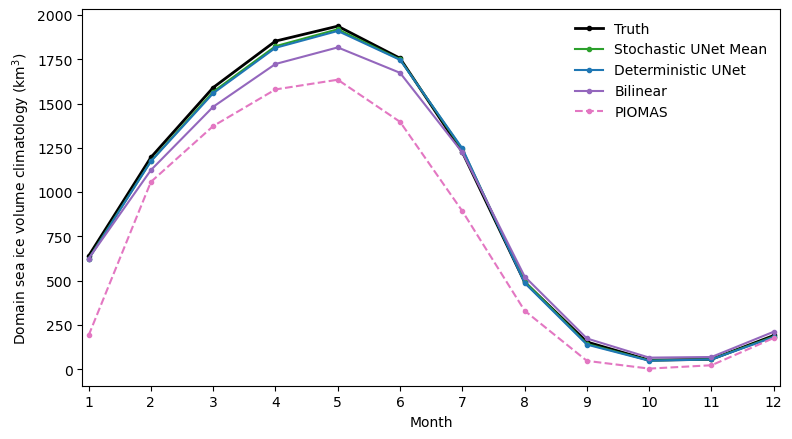

,Seasonal amplitude (km^3)
truth,1886.5
stochastic_unet_mean,1870.5
deterministic_unet,1862.6
bilinear,1752.1
piomas,1631.6


In [8]:
if use_patches:
    print("use_patches=True: skipping (no domain area to integrate over).")
else:
    vol_clim_df = vol_df.copy()
    vol_clim_df["month"] = vol_clim_df["time"].dt.month
    monthly_vol_clim = vol_clim_df.groupby("month")[
        ["truth", "stochastic_unet_mean", "deterministic_unet", "bilinear", "piomas"]
    ].mean()

    CLIM_STYLE = {
        "truth":                ("Truth", "black", "-", 2),
        "stochastic_unet_mean": ("Stochastic UNet Mean", "tab:green", "-", 1.5),
        "deterministic_unet":   ("Deterministic UNet", "tab:blue", "-", 1.5),
        "bilinear":             ("Bilinear", "tab:purple", "-", 1.5),
        "piomas":               ("PIOMAS", "tab:pink", "--", 1.5),
    }

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for col, (label, color, ls, lw) in CLIM_STYLE.items():
        ax.plot(monthly_vol_clim.index, monthly_vol_clim[col], label=label, color=color,
                 linestyle=ls, linewidth=lw, marker="o", markersize=3)
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")
    ax.set_ylabel("Domain sea ice volume climatology (km$^3$)")
    ax.legend(fontsize=10, frameon=False)
    plt.tight_layout()
    plt.xlim(0.9, 12.1)
    save_fig(fig, "v2_volume_seasonal_climatology")
    plt.show()

    vol_amplitude = (monthly_vol_clim.max() - monthly_vol_clim.min()).rename("Seasonal amplitude (km^3)")
    vol_amplitude_df = vol_amplitude.round(1).to_frame()
    save_table(vol_amplitude_df, "v2_volume_seasonal_amplitude")
    display(vol_amplitude_df)
